In [1]:
import sys
print(sys.version)

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [2]:
#importing libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3



In [3]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("customer_churn.db")

# for to Find all tables
sql_query = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

tables = pd.read_sql(sql_query, conn)

# Display table names
print("Tables in the database:")
display(tables)

# Creating a DataFrame for each table
df = {}

for table_name in tables["name"]:
    df[table_name] = pd.read_sql(
        f"SELECT * FROM {table_name}",
        conn
    )

# Close connection
conn.close()

Tables in the database:


,name
0,db_customer
1,db_subscription
2,db_support


In [4]:
#Printing table names and column names
# Connecting to the database
conn = sqlite3.connect("customer_churn.db")

# Print table names and column names
for table_name in tables["name"]:
    
    print(f"\nTable Name: {table_name}")
    
    # Get column information using PRAGMA
    columns_query = f"PRAGMA table_info({table_name});"
    
    columns = pd.read_sql(columns_query, conn)
    
    print("Columns:")
    print(columns["name"].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
df.keys()

dict_keys(['db_customer', 'db_subscription', 'db_support'])

In [6]:
df['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
# 2.Data cleaning

In [8]:
#df['db_customer'].head()
df['db_customer'].tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [9]:
df['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [10]:
#a.RENAMING COLUMN WITH NAME AS CUSTOMER_NAME
#b.DROPPING COLUMN -PINCODE & INTERESTS
#c.CHANGING DATATYPE OF COLUMN dob as INTEGER TYPE
#d.fixing the gender
#d.fixing the missing values of the country column

In [11]:
#a.RENAMING COLUMN WITH NAME AS CUSTOMER_NAME
df['db_customer'].rename(columns={'name':'customer_name'},inplace = True)
df['db_customer']

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [12]:
#b.DROPPING COLUMN -PINCODE & INTERESTS
df['db_customer'].drop(
    columns=['interests', 'pincode'],
    inplace=True
)

In [13]:
#CHANGING DATATYPE OF COLUMN dob as INTEGER TYPE
df['db_customer']['dob'] = pd.to_datetime(df['db_customer']['dob'])

In [14]:
df['db_customer']


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [15]:
#d.fixing the gender
df['db_customer']['gender']=df['db_customer']['gender'].replace({'Men':'Male','Women':'Female'})

In [16]:
df['db_customer']

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [17]:
#e.fixing the missing values of the country column

# Step 1: Create state-country mapping
state_country_mapping = (
    df['db_customer']
    .dropna(subset=['country'])
    .set_index('state')['country']
    .to_dict()
)

# Step 2: Fill missing country values using state
df['db_customer']['country'] = df['db_customer']['country'].fillna(
    df['db_customer']['state'].map(state_country_mapping)
)

In [18]:
df['db_customer']

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [19]:
# checking next data called db_subscription
df['db_subscription'].head()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [20]:
df['db_subscription'].tail()


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [21]:
df['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [22]:
#in above all date columns are in strings so we need to change their data type
columns=[' cancellation_date','renewal_date ','  subscription_start_date']
columns = [
    'cancellation_date',
    'renewal_date',
    'subscription_start_date'
]

df['db_subscription'][columns] = (
    df['db_subscription'][columns]
    .apply(pd.to_datetime)
)

In [23]:
df['db_subscription']

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41


In [24]:
df['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [25]:
#moving to another table of the dataset called db_support
df['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [26]:
df['db_support'].head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [27]:
df['db_support'].tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,NaN
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,NaN
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,NaN
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [28]:
#last columns are unnecessary so i am removing them
df['db_support']=df['db_support'].drop(columns=['col_1','comment'])

In [29]:
df['db_support']

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [30]:
df['db_support'].tail()

,customerid,complaint_date,escalations,csat_score
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [31]:
df['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 420.0 bytes


In [32]:
#HERE IN ABOVE THE TABLE INFO complaint_date is in strng so we have to change that
df['db_support']['complaint_date']=pd.to_datetime(df['db_support']['complaint_date'])

In [33]:
df['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [34]:
3.#NOW DOING FUTURE ENGINEERING AND DATA ANALYSIS
df['db_subscription']

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41


In [35]:
# Now Making a new column that named churn flag customer leaved
df['db_subscription']['customer_churn']=np.where(df['db_subscription']['cancellation_date'].notna(),1,0)

In [36]:
df['db_subscription'].head(6)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,customer_churn
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0


In [37]:
# NOW MERGING ALL THE TABLES
# NOW MERGING ALL THE TABLES

df1= (
    df['db_subscription']
    .merge(df['db_customer'], how='left', on='customerid')
    .merge(df['db_support'], how='left', on='customerid')
)

In [38]:
df1

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,customer_churn,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [39]:
df1.shape

(23, 20)

In [40]:
 df['db_subscription']['customerid'].nunique()

21

In [41]:
df['db_support'].shape

(9, 4)

In [42]:
df['db_support']['customerid'].nunique()

7

In [43]:
df['db_customer'].shape

(21, 6)

In [44]:
df['db_customer']['customerid'].nunique()

21

In [45]:
df['db_support']

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [46]:
df['db_support']['dup_custom'] = (
    df['db_support']
    .groupby('customerid')['customerid']
    .transform('count')
)

In [47]:
df['db_support']

,customerid,complaint_date,escalations,csat_score,dup_custom
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [48]:
#adding a column in db_support table naming duplicate_customer
df['db_support']['customer_complaint'] = (
    df['db_support']
    .groupby('customerid')['customerid']
    .transform('count')
)

In [49]:
df['db_support']

,customerid,complaint_date,escalations,csat_score,dup_custom,customer_complaint
0,0003-MKNFE,2024-08-28,N,60,2,2
1,0003-MKNFE,2024-08-28,Y,10,2,2
2,0013-EXCHZ,2024-01-20,Y,20,1,1
3,0013-MHZWF,2025-03-18,N,90,1,1
4,0013-SMEOE,2024-11-01,N,30,1,1
5,0017-IUDMW,2024-04-10,Y,25,1,1
6,0019-EFAEP,2024-09-27,Y,30,1,1
7,0022-TCJCI,2024-09-13,Y,10,2,2
8,0022-TCJCI,2024-09-14,N,90,2,2


In [50]:
#dropping duplicates
df['db_support']=df['db_support'].sort_values('customer_complaint').drop_duplicates('customerid',keep='last')

In [51]:
#dropping duplicates
df['db_support'].shape

(7, 6)

In [52]:
#after fixing the duplicates of the support table again merging
final_df = (
    df['db_subscription']
    .merge(df['db_customer'], how='left', on='customerid')
    .merge(df['db_support'], how='left', on='customerid')
)

In [53]:
final_df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,dup_custom,customer_complaint
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,2.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0,1.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0,1.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,arjun,Nepal,Kathmandu,Male,1993-10-29,NaT,NaN,NaN,NaN,NaN


In [54]:
df['db_support'].shape

(7, 6)

In [55]:
df['db_subscription']

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,customer_churn
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0


In [56]:
# exporting to excel csv
final_df.to_csv('churn_data_excel_csv.csv',index=False)

In [57]:
import os
print(os.getcwd())

C:\Users\Karunakar


In [58]:
# want to save in desktop
final_df.to_csv(
    r'C:\Users\Karunakar\Desktop\churn_data_excel_csv.csv',
    index=False
)

In [59]:
import os

desktop = os.path.join(os.path.expanduser("~"), "Desktop")
file_path = os.path.join(desktop, "churn_data_excel_csv.csv")

final_df.to_csv(file_path, index=False)

print("Saved to:", file_path)
print("File exists:", os.path.exists(file_path))

Saved to: C:\Users\Karunakar\Desktop\churn_data_excel_csv.csv
File exists: True


In [60]:
#data analysis
final_df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'customer_churn', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'dup_custom',
       'customer_complaint'],
      dtype='str')

In [61]:
#Now calculating customer churn rate percentage -percentage of customers who left/cancelled their service during a period
churn_rate = final_df['customer_churn'].mean()*100
print('churn rate:',round(churn_rate,2),'%')
 

churn rate: 28.57 %


In [62]:
# Retention rate - percentage of customers who stayed with the company.
retention_rate = 100 - churn_rate 
print('retention rate:',round(retention_rate ,2),'%')


retention rate: 71.43 %


In [63]:
#churn rate by plan type 
churn_with_plan = final_df.groupby('plan_type')['customer_churn'].mean().mul(100).round(2).reset_index(name='churn_rate_percentage')
churn_with_plan 

,plan_type,churn_rate_percentage
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [64]:
#churn by state+sum(revenue)+count of users
churn_rate_by_state=final_df.groupby('state').agg(churn_rate=('customer_churn','mean'),
                              total_revenue=('monthly_charges','sum'),
                              count_of_users=('customerid','nunique'))
churn_rate_by_state['churn_rate']=(churn_rate_by_state['churn_rate']*100).round(2)
churn_rate_by_state

,churn_rate,total_revenue,count_of_users
state,,,
Delhi,25.00,52.96,4
Karnataka,100.00,20.98,2
Kathmandu,0.00,20.98,2
Maharashtra,0.00,50.97,3
Meghalaya,66.67,42.97,3
Nagaland,0.00,22.99,1
Rajasthan,0.00,36.98,2
Telangana,50.00,30.98,2
Uttar Pradesh,0.00,115.98,2


In [65]:
#checking whether the data is correct or wrong
final_df['state'].value_counts()['Karnataka']

np.int64(2)

In [66]:
# churn by subscribtiops type +sum(revenue)+count of users
churn_by_subscribtions=final_df.groupby('subscription_type').agg(churn_rate=('customer_churn','mean'),
                              total_revenue=('monthly_charges','sum'),
                              count_users=('customerid','nunique'))
churn_by_subscribtions['churn_rate'] = (churn_by_subscribtions['churn_rate']*100) .round(2)

In [67]:
churn_by_subscribtions

,churn_rate,total_revenue,count_users
subscription_type,,,
Organic,0.00,145.91,9
Paid,16.67,174.94,6
Refferal,83.33,74.94,6


In [68]:
# average revenue for users
avg_revenue=final_df['monthly_charges'].mean()
print('avg_revenue:',round(avg_revenue,2))


avg_revenue: 18.85


In [69]:
final_df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'customer_churn', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'dup_custom',
       'customer_complaint'],
      dtype='str')

In [70]:
today = pd.Timestamp.today()

final_df['customer_age'] = (
    today.year
    - final_df['dob'].dt.year
    - (
        (today.month < final_df['dob'].dt.month)
        |
        (
            (today.month == final_df['dob'].dt.month)
            &
            (today.day < final_df['dob'].dt.day)
        )
    )
)

In [71]:
final_df[['customer_name','customer_age','monthly_charges']].head(4)

,customer_name,customer_age,monthly_charges
0,keshav,44,13.99
1,raghav,30,12.99
2,lalita,48,6.99
3,mohan,24,22.99


In [72]:
#Average customer tenure
#count of days user has used our service, by using cancellation date else current date
today = pd.Timestamp.today()
final_df['customer_tenure']= np.where(final_df['cancellation_date'].notna(),
                                      (final_df['cancellation_date']- final_df['subscription_start_date']).dt.days,
                                      (today-final_df['subscription_start_date']).dt.days)
tenure = final_df['customer_tenure'].mean()
print('avg_tenure:' ,round(tenure,2))

avg_tenure: 1520.14


In [73]:
# calculating revenue at loss by the churn users
churn_loss= final_df.loc[final_df['customer_churn']==1, 'monthly_charges'].sum()
print('churn_revenue_loss in k :',churn_loss)

churn_revenue_loss in k : 73.94


In [74]:
#Escalation rate:Percentage of problems that were sent to higher-level support or complaints raised by the customers
escalation_rate=(final_df['escalations']=='Y').mean()*100
print('escalation_rate:',round(escalation_rate,2),'%')

escalation_rate: 14.29 %


In [75]:
# calculating average complaint for users
avg_complaint = final_df['customer_complaint'].sum()/ final_df['customerid'].nunique()
avg_complaint

np.float64(0.42857142857142855)

In [76]:
#correlation of churn customer and escallation
final_df['escalations'].nunique()


2

In [77]:
final_df['escalation'] = np.where(
    final_df['escalations'] == 'Y',
    1,
    0
)

In [78]:
final_df['escalation']

0     0
1     0
2     0
3     0
4     1
5     0
6     0
7     0
8     0
9     0
10    0
11    1
12    0
13    1
14    0
15    0
16    0
17    0
18    0
19    0
20    0
Name: escalation, dtype: int64

In [79]:
# creating new column says churn position using churn score -churn_risk
condititons=[(final_df['churn_score']<=40),(final_df['churn_score']>40)& (final_df['churn_score']<=60),(final_df['churn_score']>60)]
choices=['low','medium','high']
final_df['churn_risk']=np.select(condititons,choices,default='unknown')

In [80]:
final_df[['churn_score','churn_risk']].head()

,churn_score,churn_risk
0,12,low
1,91,high
2,34,low
3,8,low
4,88,high


In [81]:
final_df[['churn_score','churn_risk']].tail()

,churn_score,churn_risk
16,62,high
17,27,low
18,99,high
19,7,low
20,47,medium


In [82]:
# MOVING TO DATA VISUALIZATION 
final_df[final_df['customer_churn']==1]

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,dob,complaint_date,escalations,csat_score,dup_custom,customer_complaint,customer_age,customer_tenure,escalation,churn_risk
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1995-11-23,2024-08-28,N,60.0,2.0,2.0,30,1501.0,0,high
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1990-05-05,2024-01-20,Y,20.0,1.0,1.0,36,419.0,1,high
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1976-09-21,2024-11-01,N,30.0,1.0,1.0,49,1142.0,0,high
11,0017-IUDMW,2023-03-17,Refferal,2024-03-17,Standard,Monthly,2024-05-01,Poor streaming quality,7.99,270,...,1981-06-18,2024-04-10,Y,25.0,1.0,1.0,45,411.0,1,high
13,0019-EFAEP,2022-08-25,Refferal,2024-08-25,Basic,Monthly,2024-10-31,Switched to competitor,12.99,160,...,1992-04-25,2024-09-27,Y,30.0,1.0,1.0,34,798.0,1,high
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,...,1983-12-30,2024-09-14,N,90.0,2.0,2.0,42,366.0,0,high


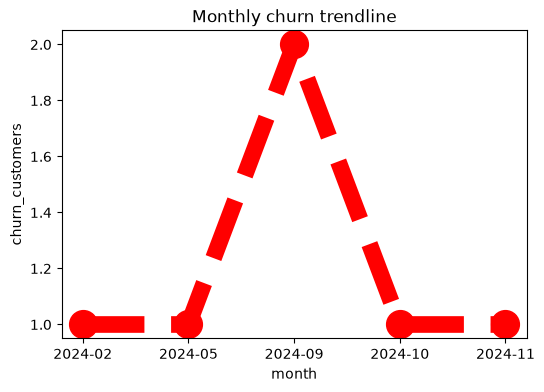

In [83]:
# Monthly churn trendline 
final_df['monthly_cancellations']=final_df['cancellation_date'].dt.to_period('M')
monthly_churn = final_df[final_df['customer_churn']==1].groupby('monthly_cancellations').size()

plt.figure(figsize=(6,4))
plt.plot(monthly_churn.index.astype('str'),monthly_churn.values,color='red',marker='o',linestyle='dashed',markersize=20,linewidth=12)
plt.title('Monthly churn trendline')
plt.xlabel('month')
plt.ylabel('churn_customers')
plt.show()

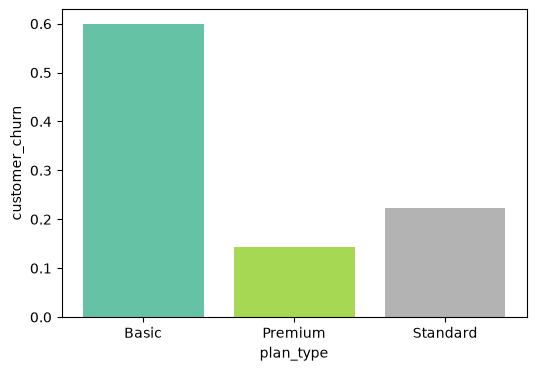

In [84]:
#churn by plan type
churn_by_type=final_df.groupby('plan_type')['customer_churn'].mean()
colors=plt.cm.Set2(np.linspace(0,1,len(churn_by_type)))
plt.figure(figsize=(6,4))
plt.bar(churn_by_type.index.astype('str'),churn_by_type.values,color=colors)
plt.xlabel('plan_type')
plt.ylabel('customer_churn')
plt.show()

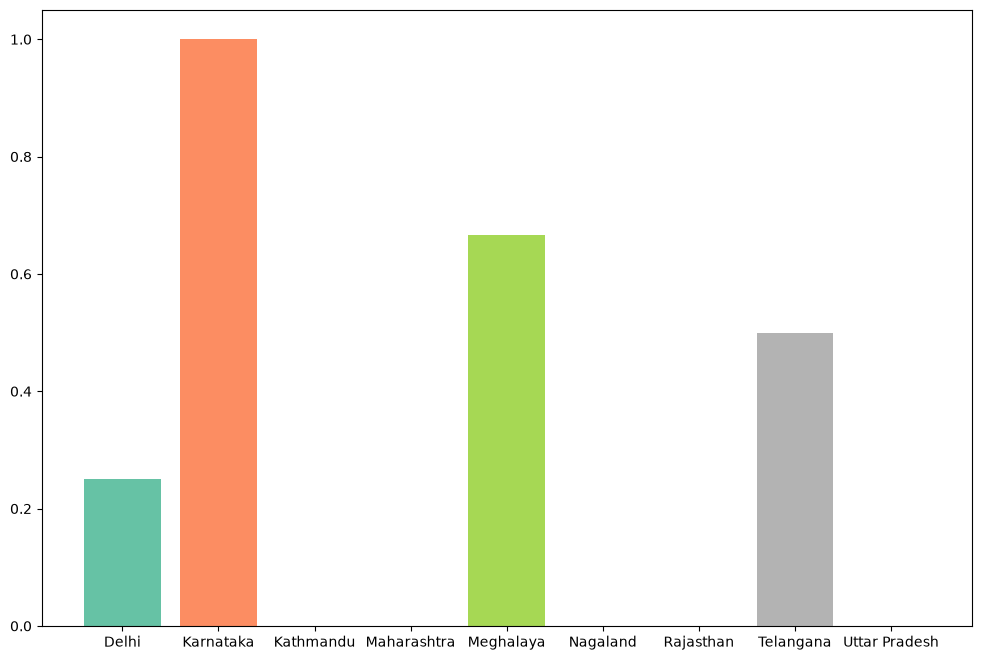

In [85]:
#churn by state
churn_by_state = final_df.groupby('state')['customer_churn'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_by_state)))

plt.figure(figsize=(12, 8))

plt.bar(churn_by_state.index.astype('str'),churn_by_state.values,color=colors)
plt.xlabel='state'
plt.ylabel='customer_churn'
plt.show()

In [86]:
# WORKING WITH SEA BORN # Select required columns
# Correct method of encoding based on priority

encoded = final_df[
    ['plan_type',
     'contract_type',
     'churn_score',
     'customer_churn',
     'churn_risk'
     ]
].copy()


# Define the correct order for each categorical column
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
}


# Convert categories into ordered numerical codes
for col, order in order_mappings.items():
       encoded[col] = pd.Categorical(
        encoded[col],
        categories=order,
        ordered=True
    ).codes


# View result
encoded.head()

C:\Users\Karunakar\AppData\Local\Temp\ipykernel_12432\3100988110.py:24: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  encoded[col] = pd.Categorical(


,plan_type,contract_type,churn_score,customer_churn,churn_risk
0,1,1,12,0,0
1,2,1,91,1,2
2,0,0,34,0,0
3,2,1,8,0,0
4,1,0,88,1,2


In [89]:
%pip install seaborn

Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


<Axes: >

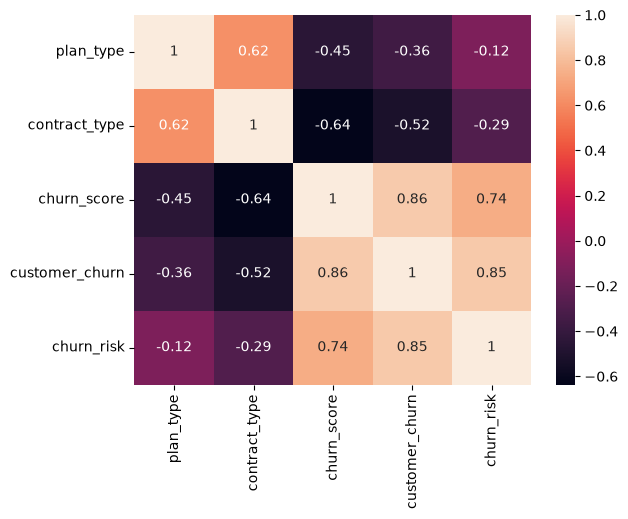

In [91]:
#heat map 
import seaborn as sns
sns.heatmap(encoded.corr(),annot=True)

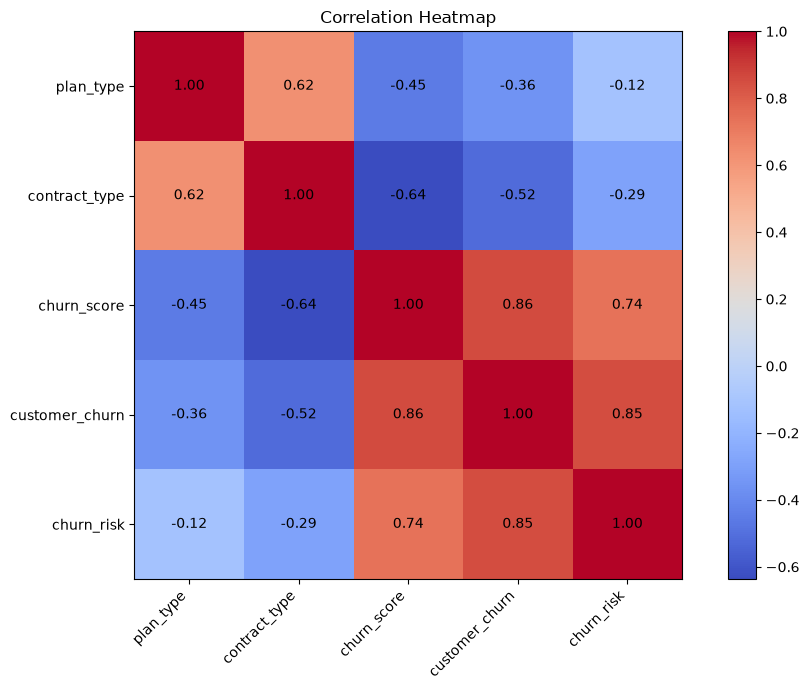

In [93]:
#heatmap using matplotlib
import matplotlib.pyplot as plt

# Calculate correlation
corr = encoded.corr()

# Create figure
plt.figure(figsize=(10, 7))

# Create heatmap
plt.imshow(corr, cmap='coolwarm')

# Add color scale
plt.colorbar()

# Add column names
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f'{corr.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

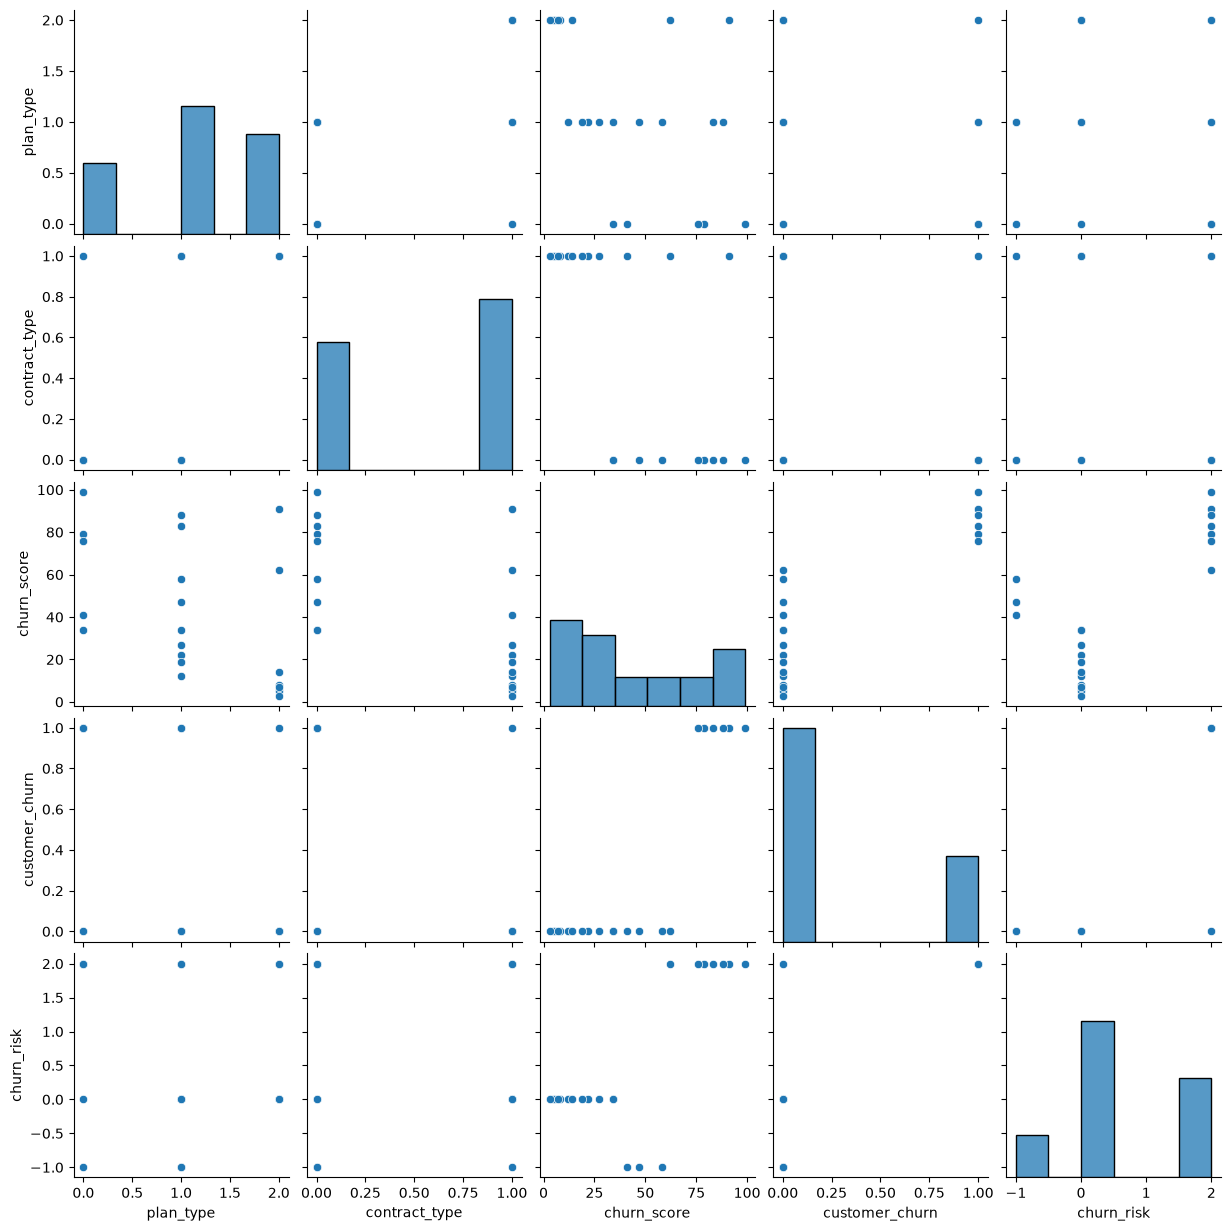

In [94]:
#pairplot
sns.pairplot(encoded)

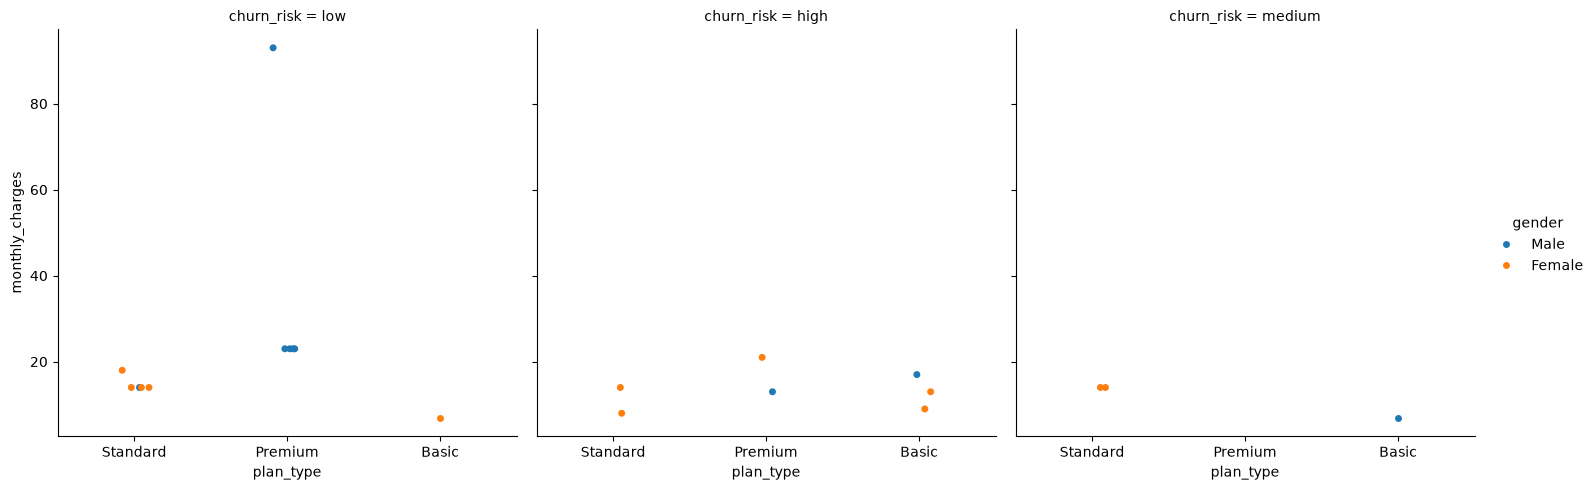

In [95]:
# catplot/facetgrid plot -multi-dim camparison
sns.catplot(data=final_df,x='plan_type',y='monthly_charges',hue='gender',col='churn_risk')


In [ ]:
#pivot tables